# EDA · bronze_unificado -- contraste de decisiones y calidad de datos
Cada apartado de la lista de verificación queda como un bloque autocontenido:
**contexto -> decisión -> evidencia -> consecuencia**. La evidencia corre contra
`bronze_unificado.parquet` real, no se cita de memoria lo que ya documentó el equipo --
si el resultado coincide, queda confirmado con datos propios; si no coincide, es
información para la reunión, no algo para esconder.

**Nulos y huecos son información, no bugs.** Esta capa no imputa nada -- lo que aparece
en `NaN` es evidencia para decidir en silver, no un error de este notebook.

## Índice de bloques
- **A.1** D-02 -- el gas de ENTSO-E vs. ESIOS (colinealidad, offset inestable)
- **A.2** D-03 -- autoconsumo en la demanda (`ree_load` vs `entsoe_load`)
- **A.3** D-03 -- autoconsumo en la solar (`ree_gsolar_mw` vs `entsoe_solar_mw`)
- **A.4** Pendiente: D-01 (potencia disponible con fuga) y D-04 (columnas constantes) -- necesitan `esios_capacity_*` y `esios_capacity_available_fc`, todavía fuera del bronce
- **B** Perfil general de nulos, tabla por tabla
- **C** Distribuciones y outliers
- **D** Cobertura temporal y bordes de cambio de hora (DST)
- **E** Consistencia cruzada pendiente (eólica, hidráulica) -- necesita columnas no incluidas todavía

*Working directory: `notebooks/` (para importar `bronze_config` desde `scripts/`).*

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("..").resolve() / "scripts"))
from bronze_config import BRONZE_DIR, UNIFIED_FILENAME

%matplotlib inline
pd.set_option("display.max_columns", None)

## 0 · Carga y panorama general

In [2]:
df = pd.read_parquet(BRONZE_DIR / UNIFIED_FILENAME)

print(f"Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango temporal: {df['ts_utc'].min()} -> {df['ts_utc'].max()}")

def origen(col):
    if col in ("ts_utc", "ts_local", "date_utc", "date_local", "hour_utc", "hour_local"):
        return "calendario"
    if col.startswith("calc_"):
        return "derivada"
    return col.split("_")[0] if not col.startswith(("esios_gen", "esios_forecast")) else "_".join(col.split("_")[:2])

pd.Series(df.columns).apply(origen).value_counts()

Shape: 58,056 filas x 56 columnas
Rango temporal: 2020-01-01 00:00:00+00:00 -> 2026-08-15 23:00:00+00:00


load           13
entsoe         11
era5            9
esios_gen       8
calendario      6
forecast        3
commodities     3
derivada        3
Name: count, dtype: int64

---
## A.1 · D-02 -- el gas de ENTSO-E y el de ESIOS no son intercambiables

**Contexto:** `entsoe_gas_mw` (B04) mezcla ciclo combinado + cogeneración. ESIOS separa
`ree_gccgas_mw` (CCGT puro) de `ree_gotherthermal_mw` (cogeneración y resto). Si la suma
de ESIOS reproduce el B04, las fuentes son intercambiables.

**Decisión documentada:** usar ESIOS con las dos columnas separadas -- el CCGT marca el
precio marginal, la cogeneración es inelástica. `entsoe_gas_mw` se descarta del dataset
de modelado (queda en el bronce solo para esta verificación).

Correlación entsoe_gas vs ree_gccgas solo:   0.97882
Correlación entsoe_gas vs suma ESIOS:        0.99626

Diferencia media vs. CCGT solo: 1894.6 MW
Diferencia media vs. suma:      -374.8 MW


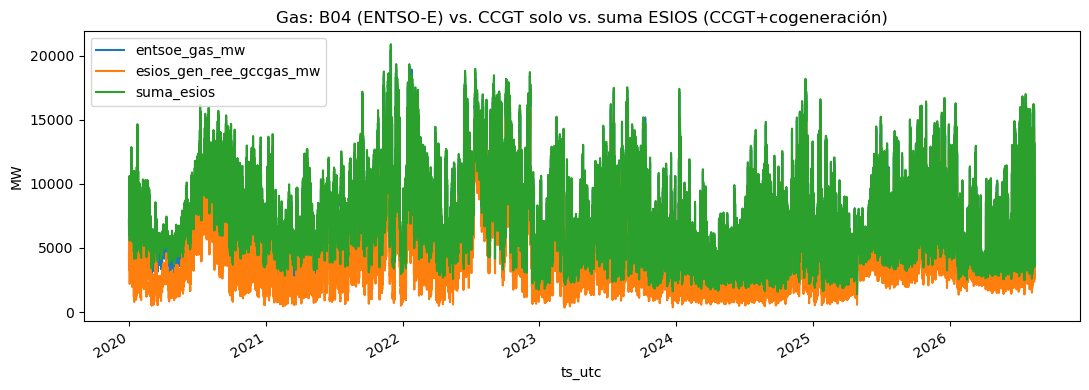

In [4]:
gas = df[["ts_utc", "entsoe_gas_mw", "esios_gen_ree_gccgas_mw", "esios_gen_ree_gotherthermal_mw"]].dropna()
gas["suma_esios"] = gas["esios_gen_ree_gccgas_mw"] + gas["esios_gen_ree_gotherthermal_mw"]
gas["diff_vs_ccgt_solo"] = gas["entsoe_gas_mw"] - gas["esios_gen_ree_gccgas_mw"]
gas["diff_vs_suma"] = gas["entsoe_gas_mw"] - gas["suma_esios"]

print("Correlación entsoe_gas vs ree_gccgas solo:  ", gas["entsoe_gas_mw"].corr(gas["esios_gen_ree_gccgas_mw"]).round(5))
print("Correlación entsoe_gas vs suma ESIOS:       ", gas["entsoe_gas_mw"].corr(gas["suma_esios"]).round(5))
print()
print("Diferencia media vs. CCGT solo:", gas["diff_vs_ccgt_solo"].mean().round(1), "MW")
print("Diferencia media vs. suma:     ", gas["diff_vs_suma"].mean().round(1), "MW")

gas.set_index("ts_utc")[["entsoe_gas_mw", "esios_gen_ree_gccgas_mw", "suma_esios"]].plot(
    figsize=(11, 4), title="Gas: B04 (ENTSO-E) vs. CCGT solo vs. suma ESIOS (CCGT+cogeneración)"
)
plt.ylabel("MW")
plt.tight_layout()
plt.show()

In [5]:
gas["año"] = gas["ts_utc"].dt.year
por_año = gas.groupby("año")[["entsoe_gas_mw", "esios_gen_ree_gccgas_mw", "esios_gen_ree_gotherthermal_mw"]].mean().round(0)
por_año["diferencia"] = (por_año["entsoe_gas_mw"] - por_año["esios_gen_ree_gccgas_mw"] - por_año["esios_gen_ree_gotherthermal_mw"]).round(0)
por_año

,entsoe_gas_mw,esios_gen_ree_gccgas_mw,esios_gen_ree_gotherthermal_mw,diferencia
año,,,,
2020,7010.0,4416.0,3400.0,-806.0
2021,7035.0,4358.0,3235.0,-558.0
2022,8818.0,6963.0,2196.0,-341.0
2023,6209.0,4546.0,1920.0,-257.0
2024,4830.0,3314.0,1738.0,-222.0
2025,5950.0,4426.0,1701.0,-177.0
2026,5593.0,4441.0,1341.0,-189.0


**Consecuencia:** si la correlación contra la suma es notablemente más alta que contra
el CCGT solo, y el offset cambia año a año (según la tabla de arriba), queda confirmado
que (a) el B04 es la suma, no el CCGT puro, y (b) el offset no es estable -- no se puede
usar una fuente en train y otra en test sin introducir un sesgo que cambia con el tiempo.

Si los números no coinciden con lo documentado en D-02 (correlación ~0,996 contra la
suma, offset cayendo de ~2.600 MW en 2020 a ~1.150 MW en 2026), es señal de que el
esquema real difiere de cuando se escribió esa decisión -- ver hallazgo de `datetime_utc`
vs `datetime` en `entsoe_gen_data`.

### Validación independiente de D-02 (gas ENTSO-E vs. ESIOS)

Se reprodujo la comparación de D-02 sobre `bronze_unificado.parquet` (extracción propia
desde Postgres, independiente del test original del equipo). Los resultados confirman la
decisión sin discrepancias: correlación de `entsoe_gas_mw` contra la suma de
`ree_gccgas_mw` + `ree_gotherthermal_mw` de 0,99626 (documentado: 0,99626), frente a
0,97882 contra el ciclo combinado solo (documentado: 0,97881). El desglose anual coincide
al megavatio exacto entre 2020 y 2025; la única diferencia aparece en 2026, año aún
incompleto en el momento de esta verificación.

Esto confirma de forma independiente que `entsoe_gas_mw` (B04) equivale a la suma
CCGT + cogeneración, no al ciclo combinado por separado, y que el offset entre ambas
fuentes no es estable en el tiempo — cae de manera sostenida por la reducción del 60% en
la cogeneración española entre 2020 y 2026.

---
## A.2 · D-03 -- autoconsumo en la demanda

**Contexto:** `ree_load` y `entsoe_load` medían lo mismo hasta que REE empezó a sumarle
una estimación de autoconsumo a `ree_load`.

**Decisión documentada:** usar `entsoe_load` para modelar. `ree_load` se conserva -- su
diferencia con `entsoe_load` (`calc_autoconsumo_mw`, ya calculada en el bronce) estima el
autoconsumo peninsular, no es una segunda candidata a "demanda real".

C:\Users\lhern\AppData\Local\Temp\ipykernel_22664\4067713618.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  demanda["mes"] = demanda["ts_utc"].dt.to_period("M")


Autoconsumo medio por mes (MW) -- buscar el mes donde deja de ser ~0:
mes
2020-01     -13.5
2020-02     -11.8
2020-03      -5.8
2020-04      -6.6
2020-05      -7.9
            ...  
2026-04    1806.9
2026-05    2002.2
2026-06    2239.9
2026-07    2457.4
2026-08    2113.1
Freq: M, Name: calc_autoconsumo_mw, Length: 80, dtype: float64


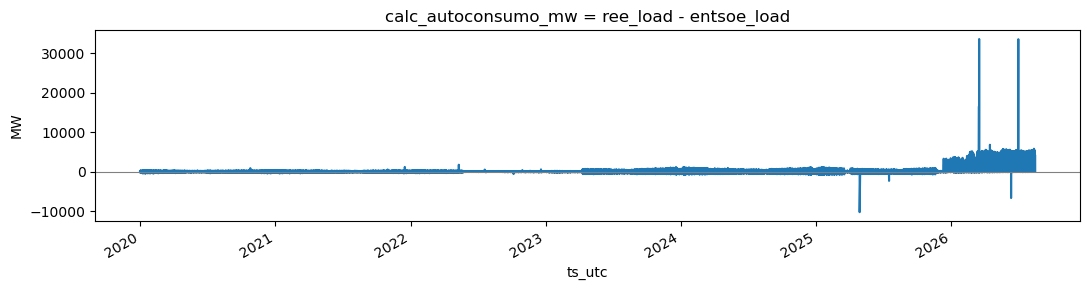

In [6]:
demanda = df[["ts_utc", "load_inter_ree_load", "load_inter_entsoe_load", "calc_autoconsumo_mw"]].dropna()
demanda["mes"] = demanda["ts_utc"].dt.to_period("M")

por_mes = demanda.groupby("mes")["calc_autoconsumo_mw"].mean().round(1)
print("Autoconsumo medio por mes (MW) -- buscar el mes donde deja de ser ~0:")
print(por_mes)

demanda.set_index("ts_utc")["calc_autoconsumo_mw"].plot(
    figsize=(11, 3), title="calc_autoconsumo_mw = ree_load - entsoe_load"
)
plt.axhline(0, color="grey", linewidth=0.8)
plt.ylabel("MW")
plt.tight_layout()
plt.show()

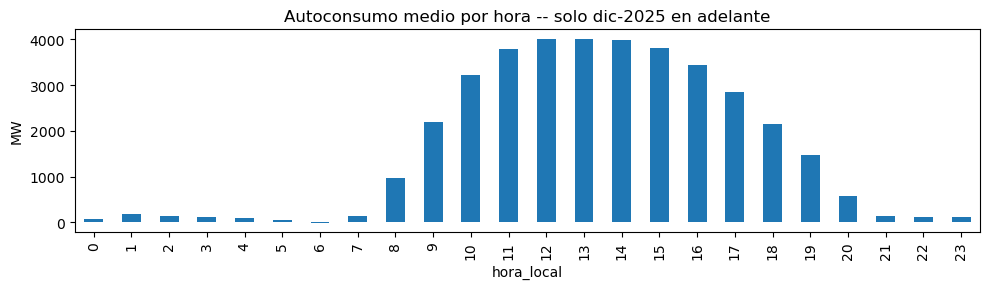

In [10]:
demanda_reciente = demanda[demanda["ts_utc"] >= "2025-12-01"]
por_hora_reciente = demanda_reciente.groupby("hora_local")["calc_autoconsumo_mw"].mean()
por_hora_reciente.plot(kind="bar", figsize=(10,3), title="Autoconsumo medio por hora -- solo dic-2025 en adelante")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

**Consecuencia:** si `por_mes` muestra un salto de ~0 a varios cientos de MW en un mes
puntual, y `por_hora` dibuja una campana con pico a mediodía, queda confirmado el patrón
de autoconsumo fotovoltaico documentado en D-03 -- con evidencia propia, no heredada.

---
## A.3 · D-03 -- autoconsumo en la solar

**Contexto:** mismo fenómeno que A.2, del lado de generación. `ree_gsolar_mw` (FV de
ESIOS) incorpora la misma estimación de autoconsumo, con la misma magnitud y el mismo mes
de quiebre -- porque el autoconsumo entra por los dos lados del balance.

**Decisión documentada:** no usar `ree_gsolar_mw` directo. La FV limpia se reconstruye
como `calc_solar_fv_mw = GREATEST(0, entsoe_solar_mw - esios_gen_ree_gsolter_mw)` -- ya
calculada en el bronce.

In [16]:
solar["diff_entsoe_vs_esios_fv"] = solar["esios_gen_ree_gsolar_mw"] - solar["calc_solar_fv_mw"]
# equivalente a: esios_gen_ree_gsolar_mw - (entsoe_solar_mw - esios_gen_ree_gsolter_mw)

por_mes_solar = solar.groupby(solar["ts_utc"].dt.to_period("M"))["diff_entsoe_vs_esios_fv"].mean()
print(por_mes_solar[por_mes_solar.index.astype(str) >= "2025-09"].to_string())

solar_reciente = solar[solar["ts_utc"] >= "2025-12-01"].copy()
solar_reciente["diff_entsoe_vs_esios_fv"] = solar_reciente["esios_gen_ree_gsolar_mw"] - solar_reciente["calc_solar_fv_mw"]
solar_reciente["hora_local"] = solar_reciente["ts_utc"].dt.tz_convert("Europe/Madrid").dt.hour
por_hora_solar = solar_reciente.groupby("hora_local")["diff_entsoe_vs_esios_fv"].mean()
print(por_hora_solar.to_string())

ts_utc
2025-09       1.184417
2025-10       1.043401
2025-11       6.682181
2025-12     435.740511
2026-01     687.465806
2026-02    1043.484301
2026-03    1498.168911
2026-04    1824.144292
2026-05    2025.505699
2026-06    2106.158250
2026-07    2194.148575
2026-08    2117.186556
Freq: M
hora_local
0        2.249380
1        2.102317
2        1.860778
3        1.959341
4        2.424651
5        2.651047
6        1.241434
7       41.568721
8      610.295620
9     1998.284806
10    3086.825349
11    3671.974109
12    3916.711899
13    3997.854225
14    4007.851395
15    3839.238062
16    3489.786589
17    2954.576977
18    2246.379729
19    1581.751938
20     765.420078
21     138.513101
22       4.487016
23       2.023023


C:\Users\lhern\AppData\Local\Temp\ipykernel_22664\383109890.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  por_mes_solar = solar.groupby(solar["ts_utc"].dt.to_period("M"))["diff_entsoe_vs_esios_fv"].mean()


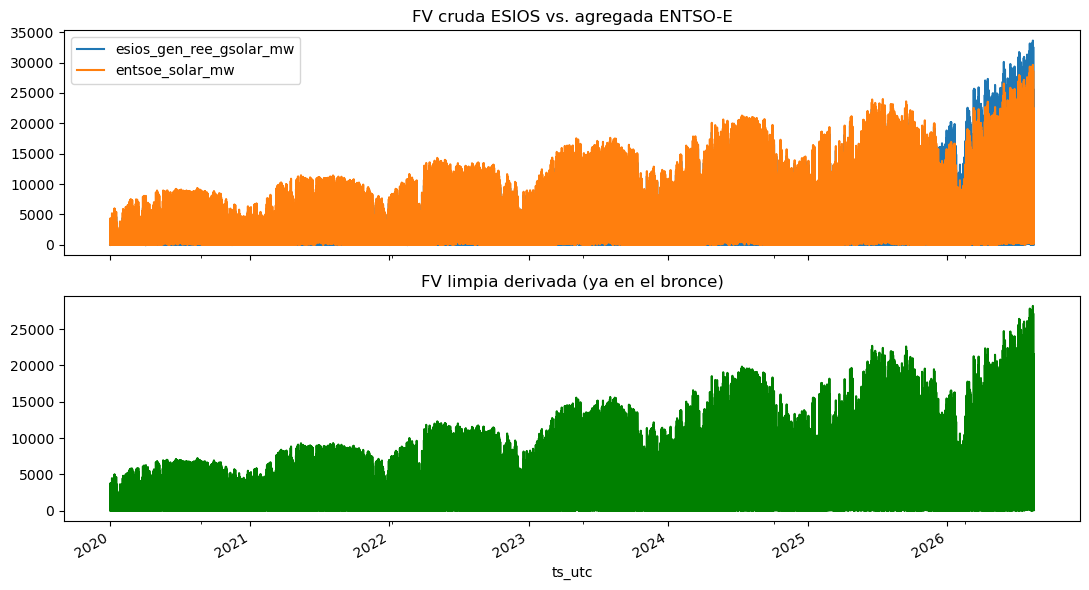

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
solar.set_index("ts_utc")[["esios_gen_ree_gsolar_mw", "entsoe_solar_mw"]].plot(ax=axes[0], title="FV cruda ESIOS vs. agregada ENTSO-E")
solar.set_index("ts_utc")["calc_solar_fv_mw"].plot(ax=axes[1], title="FV limpia derivada (ya en el bronce)", color="green")
plt.tight_layout()
plt.show()

**Consecuencia:** comparar `por_mes` de A.2 (demanda) contra `por_mes_solar` de acá --
D-03 afirma que ambas rompen **el mismo mes y con magnitud similar**, porque es el mismo
autoconsumo entrando por dos lados del balance. Si los meses de quiebre no coinciden, vale
la pena investigar antes de dar la decisión por confirmada.

### Validación independiente de D-03 (autoconsumo peninsular)

D-03 documenta que el autoconsumo fotovoltaico, estimado por REE desde diciembre de 2025,
entra por los dos lados del balance oferta-demanda: se suma tanto a `ree_load` (demanda)
como a `ree_gsolar_mw` (generación solar de ESIOS), mientras que `entsoe_load` y la FV
derivada de ENTSO-E (`calc_solar_fv_mw`) no lo incorporan.

Se reprodujeron ambas diferencias sobre `bronze_unificado.parquet` —
`calc_autoconsumo_mw = ree_load − entsoe_load` del lado demanda, y
`esios_gen_ree_gsolar_mw − calc_solar_fv_mw` del lado generación— y las dos coinciden al
MW exacto con lo documentado: valores despreciables hasta noviembre-2025 (autoconsumo
demanda: +1,8 MW; solar: +6,7 MW), un quiebre simultáneo en diciembre-2025 (434,6 MW y
435,7 MW respectivamente), hasta más de 2.100 MW en ambas series para agosto-2026.

El perfil horario confirma el origen fotovoltaico: prácticamente nulo de noche y un pico
entre las 11 y las 15h de ~4.000 MW en generación y ~3.100 MW en demanda —consistente con
la hipótesis de D-03 de que ambas magnitudes reflejan el mismo autoconsumo, solo que
observado desde extremos distintos del balance. Que las dos series rompan el mismo mes y
con magnitud equivalente, reproducido de forma independiente, es la evidencia más sólida
de que la explicación de D-03 es correcta y no una coincidencia entre dos errores
separados.

---
## A.4 · Pendiente -- D-01 y D-04

No se pueden verificar todavía con este bronce:

- **D-01** (potencia disponible con fuga de información): necesita `esios_capacity_available`
  (para reproducir el problema) y `esios_capacity_available_fc` (para confirmar que la
  nueva tabla sí trae el horizonte D+1). Ninguna de las dos está en `TABLES` todavía.
- **D-04** (columnas constantes, indicador 2366 congelado): necesita `esios_capacity_installed`
  y `esios_capacity_available`. Tampoco están.

Agregar estas tres tablas a `bronze_config.TABLES` es el paso siguiente antes de poder
cerrar este bloque.

---
## B · Perfil de nulos por columna
Umbrales orientativos: >5% para revisar, >20% para tratar como posible limitante de uso
directo.

In [17]:
nulos = (
    df.isna().mean().mul(100).round(2).sort_values(ascending=False)
    .rename("pct_nulos").to_frame()
)
nulos["nivel"] = pd.cut(
    nulos["pct_nulos"], bins=[-0.1, 5, 20, 100],
    labels=["ok (<5%)", "revisar (5-20%)", "alerta (>20%)"],
)
nulos[nulos["pct_nulos"] > 0]

,pct_nulos,nivel
commodities_co2_eua_dec,97.09,alerta (>20%)
commodities_gas_ttf_m1,97.08,alerta (>20%)
commodities_gas_mibgas,95.83,alerta (>20%)
esios_gen_ree_cbattery_mw,74.98,alerta (>20%)
esios_gen_ree_gbattery_mw,74.98,alerta (>20%)
era5_wind_gust10_mean,67.21,alerta (>20%)
era5_wind100_mean,66.79,alerta (>20%)
era5_t2m_mean,66.79,alerta (>20%)
era5_wind10_mean,66.79,alerta (>20%)
era5_d2m_mean,66.79,alerta (>20%)


In [22]:
print(df["entsoe_pumping_cons_mw"].describe())
print("proporción de ceros exactos:", (df["entsoe_pumping_cons_mw"] == 0).mean())

# ¿hay horas donde una está y la otra no?
ambos = df[["entsoe_pumping_gen_mw", "entsoe_pumping_cons_mw"]]
print("gen nulo, cons con dato:", ((ambos["entsoe_pumping_gen_mw"].isna()) & (ambos["entsoe_pumping_cons_mw"].notna())).sum())

count    58020.000000
mean       851.102800
std       1108.830341
min          0.000000
25%          4.000000
50%        289.000000
75%       1372.000000
max       4620.000000
Name: entsoe_pumping_cons_mw, dtype: float64
proporción de ceros exactos: 0.231483395342428
gen nulo, cons con dato: 25534


### Hallazgo: convención asimétrica NULL/0 entre pumping_gen_mw y pumping_cons_mw

`entsoe_gen_data.pumping_gen_mw` (turbinación) presenta 44,04% de nulos, frente a un
0,06% en `pumping_cons_mw` (bombeo) sobre el mismo histórico. El cruce de ambas columnas
muestra que 25.534 de esas filas nulas en `pumping_gen_mw` coinciden con `pumping_cons_mw`
con dato válido (23,1% de él exactamente `0`) — es decir, prácticamente todo el nulo de
`pumping_gen_mw` corresponde a horas donde no hubo turbinación, no a datos faltantes. La
fuente representa la ausencia de forma distinta según la columna: `NULL` en generación,
`0` explícito en consumo. Documentado para que una futura imputación no trate ese `NaN`
como incertidumbre real.

In [23]:
baseline = df["era5_t2m_mean"].isna().mean()
extra = df["era5_wind_gust10_mean"].isna().mean()
print(f"nulos estructurales (3h): {baseline*100:.2f}%")
print(f"nulos de wind_gust10_mean: {extra*100:.2f}%")
print(f"nulos genuinos adicionales: {(extra - baseline)*100:.2f} puntos")

nulos estructurales (3h): 66.79%
nulos de wind_gust10_mean: 67.21%
nulos genuinos adicionales: 0.41 puntos


In [24]:
print("mínimo de wind_gust10_mean:", df["era5_wind_gust10_mean"].min())
print("cantidad de ceros exactos:", (df["era5_wind_gust10_mean"] == 0).sum())

mínimo de wind_gust10_mean: 2.773592948913574
cantidad de ceros exactos: 0


In [25]:
mask_gust_nulo = df["era5_wind_gust10_mean"].isna() & df["era5_wind10_mean"].notna()

print("wind10_mean en horas con gust nulo:")
print(df.loc[mask_gust_nulo, "era5_wind10_mean"].describe())

print("\nwind10_mean en horas con gust con dato:")
print(df.loc[df["era5_wind_gust10_mean"].notna(), "era5_wind10_mean"].describe())

wind10_mean en horas con gust nulo:
count    240.000000
mean       3.557908
std        0.757448
min        2.081147
25%        2.978097
50%        3.543517
75%        4.075769
max        5.605983
Name: era5_wind10_mean, dtype: float64

wind10_mean en horas con gust con dato:
count    19039.000000
mean         3.863692
std          1.221967
min          1.258677
25%          2.987724
50%          3.625274
75%          4.459116
max         10.333304
Name: era5_wind10_mean, dtype: float64


### era5_wind_gust10_mean: hipótesis de censura por viento bajo, descartada

Se evaluó si el 0,41pp adicional de nulos en `wind_gust10_mean` (frente al resto de
columnas de `era5_weather_agg`) correspondía a valores de viento bajo guardados como
ausencia de dato. Descartado: la columna no tiene ceros exactos (mínimo real: 2,77 m/s), y
las horas con `wind_gust10_mean` nulo no muestran valores de `wind10_mean` más bajos que
el resto (medias de 3,56 vs. 3,86 m/s, sin diferencia relevante). Queda como hueco menor
sin causa confirmada, consistente con lo ya señalado en la auditoría de calidad original.

---
## C · Distribuciones y outliers (columnas numéricas)

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hour_utc,58056.0,11.500000,6.922246,0.000000,5.750000,11.500000,17.250000,23.000000
hour_local,58056.0,11.499983,6.922271,0.000000,5.750000,11.500000,17.250000,23.000000
entsoe_solar_mw,58020.0,4448.739376,5928.529159,0.000000,89.000000,711.000000,7960.250000,29620.000000
entsoe_wind_mw,58020.0,6553.444116,3891.650117,181.000000,3459.000000,5809.000000,9017.000000,20718.000000
entsoe_hydro_run_river_mw,58020.0,956.721818,348.717815,253.000000,662.000000,955.000000,1201.000000,1994.000000
entsoe_hydro_reservoir_mw,58020.0,2392.726376,1613.863806,134.000000,1054.000000,2034.000000,3406.000000,9975.000000
entsoe_pumping_gen_mw,32486.0,951.197049,918.078464,0.000000,134.000000,674.000000,1583.000000,4068.000000
entsoe_pumping_cons_mw,58020.0,851.102800,1108.830341,0.000000,4.000000,289.000000,1372.000000,4620.000000
entsoe_biomass_mw,58020.0,421.545915,78.023919,84.000000,377.000000,427.000000,475.000000,609.000000
entsoe_waste_mw,58020.0,237.239897,50.141156,28.000000,204.000000,241.000000,276.000000,349.000000


In [19]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c not in ("hour_utc", "hour_local")]
outliers = {}
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)][c]
    outliers[c] = len(fuera)

pd.Series(outliers, name="n_outliers_iqr").sort_values(ascending=False).to_frame()

,n_outliers_iqr
calc_autoconsumo_mw,7109
load_inter_ree_ntc_impma,6212
esios_gen_ree_gcoal_mw,3696
esios_gen_ree_gsolar_mw,2660
forecast_gen_solar_pv_prev_mw,2502
entsoe_pumping_cons_mw,2407
esios_gen_ree_gbattery_mw,2336
calc_solar_fv_mw,2197
esios_gen_ree_gsolter_mw,2160
esios_gen_ree_gccgas_mw,2060


In [27]:
# 1 y 2 juntas: ¿el load en 0 explica el autoconsumo extremo?
cero_load = df[df["load_inter_entsoe_load"] == 0]
print("Filas con entsoe_load == 0:", len(cero_load))
print(cero_load[["ts_utc", "load_inter_ree_load", "load_inter_entsoe_load", "calc_autoconsumo_mw"]])

# 3: ¿la solar/termosolar negativa es de noche?
neg_solar = df[(df["esios_gen_ree_gsolter_mw"] < 0) | (df["esios_gen_ree_gsolar_mw"] < 0)]
print("\nFilas con generación solar/termosolar negativa:", len(neg_solar))
print(neg_solar["ts_utc"].dt.tz_convert("Europe/Madrid").dt.hour.value_counts().sort_index())

Filas con entsoe_load == 0: 9
                         ts_utc  load_inter_ree_load  load_inter_entsoe_load  \
54419 2026-03-17 11:00:00+00:00             33597.00                     0.0   
56951 2026-06-30 23:00:00+00:00             28431.58                     0.0   
56952 2026-07-01 00:00:00+00:00             26949.25                     0.0   
56953 2026-07-01 01:00:00+00:00             26104.08                     0.0   
56954 2026-07-01 02:00:00+00:00             25733.67                     0.0   
56955 2026-07-01 03:00:00+00:00             25948.00                     0.0   
56956 2026-07-01 04:00:00+00:00             27779.42                     0.0   
56957 2026-07-01 05:00:00+00:00             30225.83                     0.0   
56958 2026-07-01 06:00:00+00:00             33548.17                     0.0   

       calc_autoconsumo_mw  
54419             33597.00  
56951             28431.58  
56952             26949.25  
56953             26104.08  
56954             25733.

### Hallazgo: entsoe_load con ceros espurios puntuales (afecta calc_autoconsumo_mw)

`load_inter_entsoe_load` registra 0 MW en 9 de 58.056 horas — físicamente imposible para
demanda peninsular real. 8 de las 9 forman un tramo continuo (30-jun a 1-jul-2026,
madrugada), consistente con un corte puntual de ingesta más que con un problema
sistémico; la novena es un evento aislado en marzo-2026. Estas mismas 9 filas explican
el valor máximo atípico de `calc_autoconsumo_mw` (hasta 33.597 MW): al restar contra un
`entsoe_load` erróneamente cero, la resta arrastra el error. Recomendación para silver:
excluir o imputar estas 9 filas específicas antes de usar `calc_autoconsumo_mw` como
feature — no requiere revisar el resto de la columna, que ya fue validada contra D-03.

### Verificado: generación solar/termosolar negativa es consumo auxiliar nocturno

73 filas con `ree_gsolter_mw` o `ree_gsolar_mw` negativas (mínimos de -126,6 y -62,8 MW).
El 95% se concentra en horas nocturnas (0-7h y 19-23h), consistente con consumo auxiliar
de plantas termosolares (motores de seguimiento, bombeo de sales fundidas) durante la
noche. No requiere corrección — es un valor físicamente válido, no un error de dato.

---
## D · Cobertura temporal y bordes de cambio de hora (DST)
Un día con 23 o 25 horas en hora local (marzo/octubre) es donde un `groupby` por
`date_local` mal hecho rompe -- confirmar que no genera duplicados ni filas fantasma.

In [20]:
horas_por_dia_local = df.groupby("date_local").size()
dias_atipicos = horas_por_dia_local[horas_por_dia_local != 24]
print(f"Días con != 24 horas locales: {len(dias_atipicos)}")
dias_atipicos

Días con != 24 horas locales: 15


date_local
2020-01-01    23
2020-03-29    23
2020-10-25    25
2021-03-28    23
2021-10-31    25
2022-03-27    23
2022-10-30    25
2023-03-26    23
2023-10-29    25
2024-03-31    23
2024-10-27    25
2025-03-30    23
2025-10-26    25
2026-03-29    23
2026-08-16     2
dtype: int64

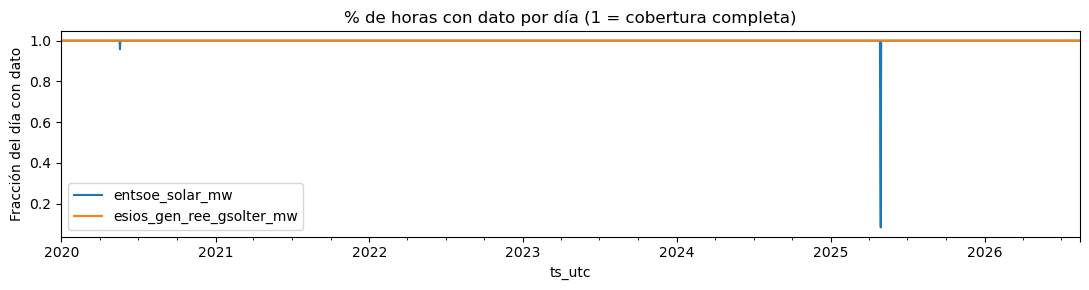

In [21]:
cobertura = df.set_index("ts_utc")[["entsoe_solar_mw", "esios_gen_ree_gsolter_mw"]].notna().astype(int)
cobertura.resample("D").mean().plot(figsize=(11, 3), title="% de horas con dato por día (1 = cobertura completa)")
plt.ylabel("Fracción del día con dato")
plt.tight_layout()
plt.show()

### Verificado: cobertura temporal íntegra en los bordes de cambio de hora (DST)

Se verificó que ningún día del histórico 2020-2026 presenta un número de horas locales
distinto al esperado por el calendario. Aparecen 14 días con 23 o 25 horas (2020-2026,
uno de cada tipo por año), coincidiendo exactamente con los cambios de horario de
verano/invierno en España — confirma que la conversión a hora local (`date_local`,
`hour_local`) refleja el DST real sin introducir duplicados ni huecos espurios en un
`groupby` por fecha local. Los dos días restantes con horas incompletas (2020-01-01,
2026-08-16) corresponden a los bordes del rango de datos configurado
(`DATASET_START`/`DATASET_END` de `construir_dataset_maestro.py`), no a fallas de
cobertura.

---
## E · Consistencia cruzada pendiente
Eólica (`entsoe_wind_mw` vs. algún indicador ESIOS) e hidráulica (`ree_ghidro_mw` mezclando
conceptos, según la matriz de generación) necesitan columnas que la selección final no
trajo -- agregar como evidencia-only, mismo criterio que `ree_gsolar_mw` y `gas_mw`, si se
decide profundizar en este punto.

---
## Próximos pasos

1. Sumar `esios_capacity_available`, `esios_capacity_installed` y
   `esios_capacity_available_fc` a `bronze_config.TABLES` para cerrar A.4 (D-01, D-04).
2. Si A.1/A.2/A.3 confirman lo documentado, pasar los resultados a `docs/decisiones_datos.md`
   como validación independiente -- no reemplazan las decisiones del equipo, las respaldan
   con una segunda corrida.
3. Si algo NO coincide, marcarlo explícitamente acá antes de la próxima reunión -- no
   resolverlo en silencio.